In [11]:
from tensorflow import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_addons as tfa

np.random.seed(123)

In [12]:
def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)

x_train, y_train = readucr("FordA_TRAIN.tsv")
x_test, y_test = readucr("FordA_TEST.tsv")

In [13]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

print(x_train.shape)

(3601, 500, 1)


In [14]:
y_train[y_train==-1] = 0
y_test[y_test==-1] = 0

In [15]:
print(y_train[:10])

[0 1 0 0 0 1 1 1 1 1]


In [16]:
idx = np.random.permutation(len(x_train))
x_train = x_train[idx]
y_train = y_train[idx]

In [17]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

## Build a model

In [18]:
input_layer = keras.layers.Input((500, 1))

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(input_layer)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.models.Model(inputs=input_layer, outputs=x)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 500, 1)]          0         
                                                                 
 conv1d_3 (Conv1D)           (None, 500, 64)           256       
                                                                 
 batch_normalization_3 (Batc  (None, 500, 64)          256       
 hNormalization)                                                 
                                                                 
 re_lu_3 (ReLU)              (None, 500, 64)           0         
                                                                 
 conv1d_4 (Conv1D)           (None, 500, 64)           12352     
                                                                 
 batch_normalization_4 (Batc  (None, 500, 64)          256       
 hNormalization)                                           

## Train the model

In [19]:
epochs = 150
batch_size = 64

loss_func = tfa.losses.SigmoidFocalCrossEntropy(alpha=0.5)
model.compile(optimizer="adam",
              loss=loss_func,
              metrics=["accuracy"])
history = model.fit(train_ds,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    verbose=2)

Epoch 1/150
113/113 - 13s - loss: 0.0747 - accuracy: 0.6818 - val_loss: 0.0948 - val_accuracy: 0.4841 - 13s/epoch - 116ms/step
Epoch 2/150
113/113 - 11s - loss: 0.0577 - accuracy: 0.7720 - val_loss: 0.1095 - val_accuracy: 0.4841 - 11s/epoch - 97ms/step
Epoch 3/150
113/113 - 9s - loss: 0.0542 - accuracy: 0.7901 - val_loss: 0.1462 - val_accuracy: 0.4841 - 9s/epoch - 80ms/step
Epoch 4/150
113/113 - 10s - loss: 0.0527 - accuracy: 0.7956 - val_loss: 0.0929 - val_accuracy: 0.5386 - 10s/epoch - 91ms/step
Epoch 5/150
113/113 - 10s - loss: 0.0513 - accuracy: 0.8062 - val_loss: 0.0893 - val_accuracy: 0.6250 - 10s/epoch - 88ms/step
Epoch 6/150
113/113 - 11s - loss: 0.0501 - accuracy: 0.8101 - val_loss: 0.0572 - val_accuracy: 0.7197 - 11s/epoch - 93ms/step
Epoch 7/150
113/113 - 10s - loss: 0.0491 - accuracy: 0.8212 - val_loss: 0.0456 - val_accuracy: 0.8492 - 10s/epoch - 90ms/step
Epoch 8/150
113/113 - 11s - loss: 0.0479 - accuracy: 0.8250 - val_loss: 0.0445 - val_accuracy: 0.8470 - 11s/epoch - 93m

Epoch 66/150
113/113 - 17s - loss: 0.0150 - accuracy: 0.9617 - val_loss: 0.0384 - val_accuracy: 0.8598 - 17s/epoch - 149ms/step
Epoch 67/150
113/113 - 16s - loss: 0.0152 - accuracy: 0.9600 - val_loss: 0.0427 - val_accuracy: 0.8545 - 16s/epoch - 146ms/step
Epoch 68/150
113/113 - 17s - loss: 0.0148 - accuracy: 0.9608 - val_loss: 0.1007 - val_accuracy: 0.6818 - 17s/epoch - 154ms/step
Epoch 69/150
113/113 - 18s - loss: 0.0149 - accuracy: 0.9611 - val_loss: 0.0395 - val_accuracy: 0.8659 - 18s/epoch - 159ms/step
Epoch 70/150
113/113 - 18s - loss: 0.0146 - accuracy: 0.9614 - val_loss: 0.0985 - val_accuracy: 0.6758 - 18s/epoch - 156ms/step
Epoch 71/150
113/113 - 18s - loss: 0.0144 - accuracy: 0.9622 - val_loss: 0.2611 - val_accuracy: 0.6902 - 18s/epoch - 157ms/step
Epoch 72/150
113/113 - 18s - loss: 0.0143 - accuracy: 0.9633 - val_loss: 0.0165 - val_accuracy: 0.9598 - 18s/epoch - 158ms/step
Epoch 73/150
113/113 - 18s - loss: 0.0145 - accuracy: 0.9631 - val_loss: 0.0159 - val_accuracy: 0.9636 -

Epoch 130/150
113/113 - 17s - loss: 0.0102 - accuracy: 0.9733 - val_loss: 0.0157 - val_accuracy: 0.9621 - 17s/epoch - 155ms/step
Epoch 131/150
113/113 - 18s - loss: 0.0102 - accuracy: 0.9708 - val_loss: 0.0223 - val_accuracy: 0.9348 - 18s/epoch - 156ms/step
Epoch 132/150
113/113 - 18s - loss: 0.0100 - accuracy: 0.9700 - val_loss: 0.5651 - val_accuracy: 0.5159 - 18s/epoch - 157ms/step
Epoch 133/150
113/113 - 17s - loss: 0.0101 - accuracy: 0.9706 - val_loss: 0.0211 - val_accuracy: 0.9402 - 17s/epoch - 154ms/step
Epoch 134/150
113/113 - 16s - loss: 0.0107 - accuracy: 0.9714 - val_loss: 0.3422 - val_accuracy: 0.5553 - 16s/epoch - 144ms/step
Epoch 135/150
113/113 - 17s - loss: 0.0103 - accuracy: 0.9700 - val_loss: 0.1956 - val_accuracy: 0.5902 - 17s/epoch - 147ms/step
Epoch 136/150
113/113 - 18s - loss: 0.0100 - accuracy: 0.9728 - val_loss: 0.0262 - val_accuracy: 0.9364 - 18s/epoch - 156ms/step
Epoch 137/150
113/113 - 18s - loss: 0.0100 - accuracy: 0.9708 - val_loss: 0.0825 - val_accuracy: 

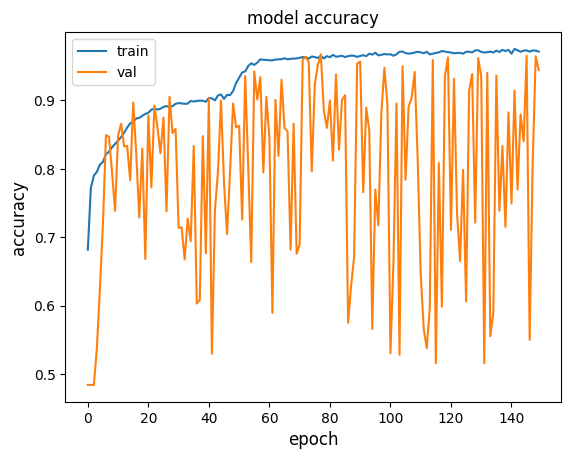

In [20]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()